In [183]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report

print("=== DEPLOYED SYSTEM LIBRARY VERSIONS ===")
print(f"Pandas Library Version: {pd.__version__}")
print(f"NumPy Library Version: {np.__version__}")
print(f"Matplotlib Engine Version: {matplotlib.__version__}")
print(f"Seaborn Visualization Version: {sns.__version__}")

=== DEPLOYED SYSTEM LIBRARY VERSIONS ===
Pandas Library Version: 3.0.3
NumPy Library Version: 2.4.6
Matplotlib Engine Version: 3.10.9
Seaborn Visualization Version: 0.13.2


In [184]:
# Set seed for reproducibility
np.random.seed(42)
n_samples = 400

# Generating baseline column vectors
customer_id = np.arange(1001, 1001 + n_samples)
age_vector = np.random.randint(18, 66, size=n_samples)
salary_vector = np.random.normal(70000, 25000, size=n_samples).round(2)
purchase_vector = np.random.poisson(5, size=n_samples)
gender_choices = np.random.choice(['Male', 'Female'], size=n_samples)
city_choices = np.random.choice(['Kathmandu', 'Pokhara', 'Lalitpur'], size=n_samples)

# Embed specific conditional logic to guide the future Decision Tree splits
subscription_choices = []
for i in range(n_samples):
    if purchase_vector[i] > 5 or (age_vector[i] > 40 and salary_vector[i] > 65000):
        subscription_choices.append('Yes')
    else:
        subscription_choices.append('No')

# Structural DataFrame configuration
df = pd.DataFrame({
    'ID': customer_id,
    'Age': age_vector,
    'Salary': salary_vector,
    'Purchase_Count': purchase_vector,
    'Gender': gender_choices,
    'City': city_choices,
    'Subscribed': subscription_choices
})

print(f"Success: Base dataset created with structural matrix footprint: {df.shape}")
df.head()

Success: Base dataset created with structural matrix footprint: (400, 7)


,ID,Age,Salary,Purchase_Count,Gender,City,Subscribed
0,1001,56,93850.04,4,Female,Kathmandu,Yes
1,1002,46,86284.78,9,Male,Kathmandu,Yes
2,1003,32,62118.27,7,Male,Kathmandu,Yes
3,1004,60,88974.23,5,Female,Kathmandu,Yes
4,1005,25,50679.37,2,Male,Lalitpur,No


In [185]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [186]:
from sklearn.metrics import confusion_matrix

In [187]:
# 1. Missing Values (Simulating incomplete profile records)
missing_indices = np.random.choice(df.index, size=10, replace=False)
df.loc[missing_indices, 'Age'] = np.nan

# 2. Impossible / Out-of-Range values (Simulating form entry/sensor faults)
df.loc[5, 'Age'] = -7
df.loc[12, 'Salary'] = 9999999.00

# 3. Unrecognized Categories (Simulating inconsistent formatting variations)
df.loc[18, 'Subscribed'] = 'yup'
df.loc[35, 'Subscribed'] = 'maybe'
df.loc[25, 'Gender'] = 'M/F'

# 4. Duplicate Rows (Simulating repeated API calls or resubmissions)
df = pd.concat([df, df.iloc[0:5]], ignore_index=True)

# Write out corrupt baseline matrix to disk
df.to_csv('corrupted_customer_dataset.csv', index=False)
print("Noise injection operational pipeline finalized.")

Noise injection operational pipeline finalized.


In [188]:
print("=== STRUCTURAL SHAPE PROFILE ===")
print(f"DataFrame Rows & Columns Dimensions: {df.shape}")
print(f"Dimensional Depth: {df.ndim} | Total Matrix Cell Size: {df.size}")

print("\n=== MISSING DATA MATRIX MAP ===")
print(df.isnull().sum())

print("\n=== QUANTITATIVE RANGE EVALUATION ===")
print(df[['Age', 'Salary']].describe())

print("\n=== CATEGORICAL CONSISTENCY SCAN ===")
print("Gender Field Balance:\n", df['Gender'].value_counts())
print("\nSubscribed Class Balance:\n", df['Subscribed'].value_counts())

print("\n=== ROW DUPLICATION VERIFICATION ===")
print(f"Identified Identical Rows Count: {df.duplicated().sum()}")

=== STRUCTURAL SHAPE PROFILE ===
DataFrame Rows & Columns Dimensions: (405, 7)
Dimensional Depth: 2 | Total Matrix Cell Size: 2835

=== MISSING DATA MATRIX MAP ===
ID                 0
Age               10
Salary             0
Purchase_Count     0
Gender             0
City               0
Subscribed         0
dtype: int64

=== QUANTITATIVE RANGE EVALUATION ===
              Age        Salary
count  395.000000  4.050000e+02
mean    41.843038  9.430838e+04
std     14.125280  4.940451e+05
min     -7.000000 -1.103168e+04
25%     30.000000  5.250686e+04
50%     43.000000  7.013109e+04
75%     53.000000  8.635914e+04
max     65.000000  9.999999e+06

=== CATEGORICAL CONSISTENCY SCAN ===
Gender Field Balance:
 Gender
Male      208
Female    196
M/F         1
Name: count, dtype: int64

Subscribed Class Balance:
 Subscribed
Yes      231
No       172
yup        1
maybe      1
Name: count, dtype: int64

=== ROW DUPLICATION VERIFICATION ===
Identified Identical Rows Count: 5


In [189]:
# 1. Resolution of Missing Values via Skew-Resistant Median Imputation
df['Age'] = df['Age'].fillna(df['Age'].median())
# 1. Resolution of Missing Values via Skew-Resistant Median Imputation
df['Age'] = df['Age'].fillna(df['Age'].median())

# 2. Filtering Out-of-Range Boundaries
df.loc[df['Age'] < 18, 'Age'] = df['Age'].median()

# Treat salary outliers by clamping them to the mean of valid profiles
salary_mean_clean = df[df['Salary'] < 500000]['Salary'].mean()
df.loc[df['Salary'] > 500000, 'Salary'] = salary_mean_clean

# 3. Standardizing Categorical Anomalies and Imputing Unknown Labels
df['Subscribed'] = df['Subscribed'].replace({'yup': 'Yes', 'maybe': np.nan})
df['Subscribed'] = df['Subscribed'].fillna(df['Subscribed'].mode()[0])
df['Gender'] = df['Gender'].replace({'M/F': df['Gender'].mode()[0]})

# 4. Dropping Duplicated Rows
df = df.drop_duplicates()

print("=== POST-CLEAN VALIDATION LOG ===")
print(f"Remaining Missing Matrices Count: {df.isnull().sum().sum()}")
print(f"Remaining Duplicate Records Count: {df.duplicated().sum()}")

=== POST-CLEAN VALIDATION LOG ===
Remaining Missing Matrices Count: 0
Remaining Duplicate Records Count: 0


In [190]:
# Encode binary structures with explicit label mappings
label_transformer = LabelEncoder()
df['Gender'] = label_transformer.fit_transform(df['Gender'])
df['Subscribed'] = label_transformer.fit_transform(df['Subscribed'])

# Expand multi-class nominal profiles via One-Hot Dummy Vectorization
df_model = pd.get_dummies(df.drop(columns=['ID']), columns=['City'], drop_first=True)

# Separate predictors from target variables
X = df_model.drop(columns=['Subscribed'])
y = df_model['Subscribed']

# Perform a clean 80/20 train/test structural split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("=== PARTITION SHAPE SIGNATURES ===")
print(f"X_train Shape (Predictors Partition): {X_train.shape}")
print(f"X_test Shape (Validation Partition):  {X_test.shape}")

=== PARTITION SHAPE SIGNATURES ===
X_train Shape (Predictors Partition): (320, 6)
X_test Shape (Validation Partition):  (80, 6)


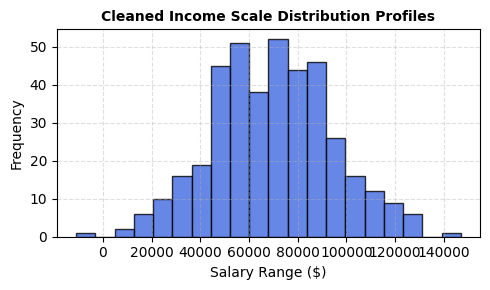

In [191]:
# Visualization 1: Cleaned Feature Scale Distribution
plt.figure(figsize=(5, 3))
df['Salary'].hist(bins=20, color='royalblue', edgecolor='black', alpha=0.8)
plt.title('Cleaned Income Scale Distribution Profiles', fontsize=10, fontweight='bold')
plt.xlabel('Salary Range ($)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()



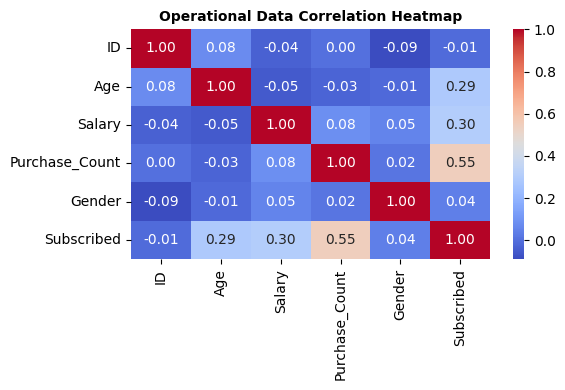

In [192]:
# Visualization 2: Feature Matrix Correlation Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Operational Data Correlation Heatmap', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

In [193]:
# Instantiating the tree using a controlled structural depth to prevent overfitting
model_tree = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
model_tree.fit(X_train, y_train)

# Generate test array predictions
y_pred = model_tree.predict(X_test)

print("=== CLASSIFIER MODEL PERFORMANCE SCORECARD ===")
print(f"Overall Model Accuracy Evaluation: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Detailed Precision Metrics:\n", classification_report(y_test, y_pred))

=== CLASSIFIER MODEL PERFORMANCE SCORECARD ===
Overall Model Accuracy Evaluation: 100.00%

Classification Detailed Precision Metrics:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        32
           1       1.00      1.00      1.00        48

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [194]:
feature_names = model.feature_names_in_

importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

          Feature  Importance
2          Salary    0.308551
0              ID    0.280527
1             Age    0.237463
3  Purchase_Count    0.118828
5            City    0.042754
4          Gender    0.011876


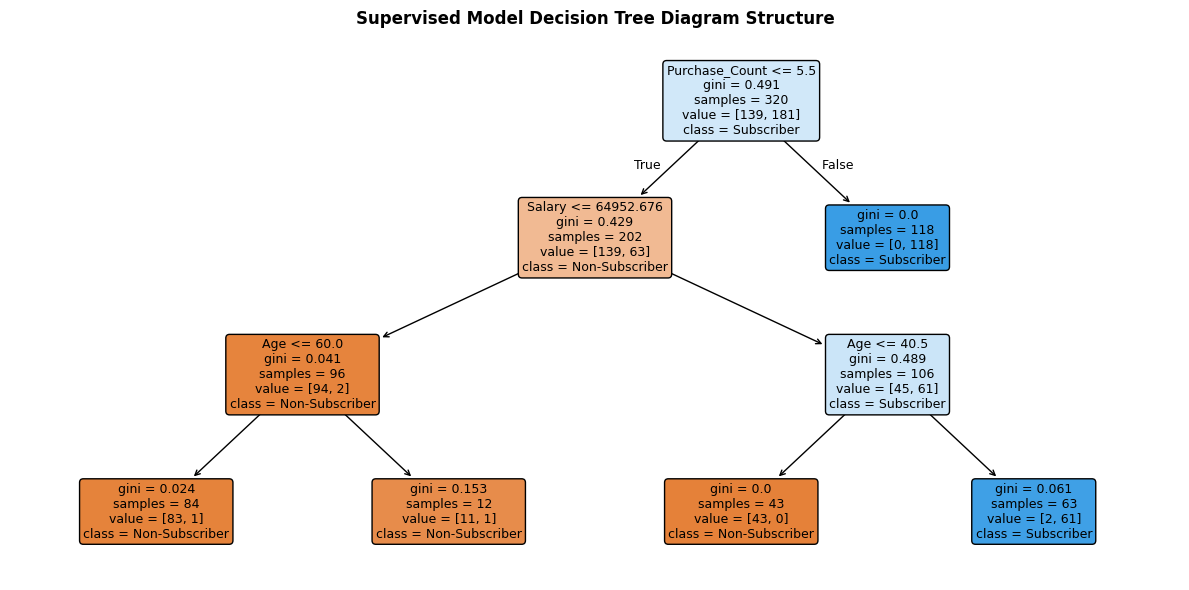

In [195]:
plt.figure(figsize=(12, 6))
plot_tree(
    model_tree,
    feature_names=list(X.columns),
    class_names=['Non-Subscriber', 'Subscriber'],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title('Supervised Model Decision Tree Diagram Structure', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

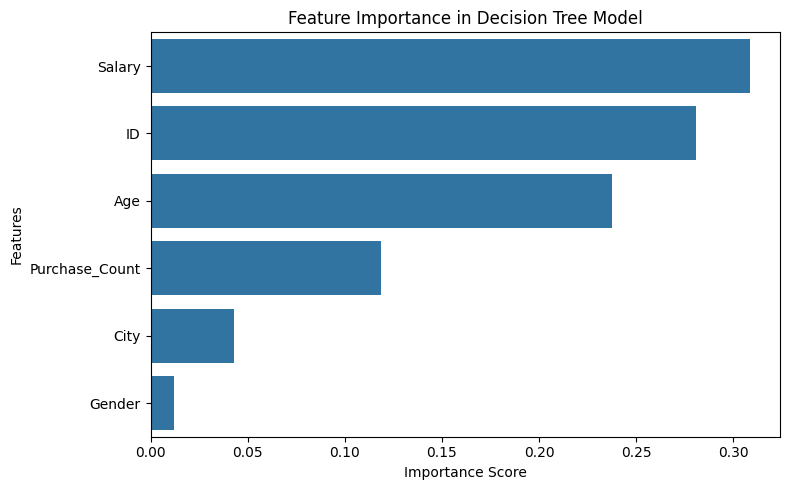

In [196]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance in Decision Tree Model')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.tight_layout()
plt.show()

In [ ]:
print(df.head())
print(df.shape)

     ID   Age    Salary  Purchase_Count  Gender       City  Subscribed
0  1001  56.0  93850.04               4       0  Kathmandu           1
1  1002  46.0  86284.78               9       1  Kathmandu           1
2  1003  32.0  62118.27               7       1  Kathmandu           1
3  1004  60.0  88974.23               5       0  Kathmandu           1
4  1005  25.0  50679.37               2       1   Lalitpur           0
(400, 7)


In [ ]:
import os
for file in os.listdir():
    print(file)

corrupted_customer_dataset.csv
synthetic_dataset.csv
week_5_Assignment.ipynb
week_6_Assignment.ipynb


In [ ]:
import pandas as pd

df = pd.read_csv("synthetic_dataset.csv")

print(df.head())
print(df.shape)

     ID  Age    Salary  Purchase_Count  Gender Subscribed       City
0  1001   56  93850.04               4  Female         No   Lalitpur
1  1002   46  86284.78               9    Male        Yes    Pokhara
2  1003   32  62118.27               7    Male         No    Pokhara
3  1004   60  88974.23               5  Female        Yes  Kathmandu
4  1005   25  50679.37               2    Male        Yes  Kathmandu
(400, 7)


In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

le = LabelEncoder()

df_encoded['Gender'] = le.fit_transform(df_encoded['Gender'])
df_encoded['Subscribed'] = le.fit_transform(df_encoded['Subscribed'])
df_encoded['City'] = le.fit_transform(df_encoded['City'])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
import pandas as pd

df = pd.read_csv("synthetic_dataset.csv")

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

le = LabelEncoder()

df_encoded['Gender'] = le.fit_transform(df_encoded['Gender'])
df_encoded['Subscribed'] = le.fit_transform(df_encoded['Subscribed'])
df_encoded['City'] = le.fit_transform(df_encoded['City'])

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

le = LabelEncoder()

df_encoded['Gender'] = le.fit_transform(df_encoded['Gender'])
df_encoded['Subscribed'] = le.fit_transform(df_encoded['Subscribed'])
df_encoded['City'] = le.fit_transform(df_encoded['City'])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model_tree = DecisionTreeClassifier(random_state=42)
model_tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load dataset
df = pd.read_csv("synthetic_dataset.csv")

# Create a copy
df_encoded = df.copy()

# Encode categorical columns
le = LabelEncoder()

df_encoded["Gender"] = le.fit_transform(df_encoded["Gender"])
df_encoded["Subscribed"] = le.fit_transform(df_encoded["Subscribed"])
df_encoded["City"] = le.fit_transform(df_encoded["City"])

# Features and Target
X = df_encoded.drop("Subscribed", axis=1)
y = df_encoded["Subscribed"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (400, 6)
y Shape: (400,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(320, 6)
(80, 6)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

model_tree = DecisionTreeClassifier(random_state=42)

model_tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model_tree = DecisionTreeClassifier(random_state=42)

model_tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [ ]:
print("Number of X columns:", len(X.columns))
print("Number of model features:", len(model.feature_importances_))
print("X columns:", list(X.columns))

Number of X columns: 7
Number of model features: 6
X columns: ['ID', 'Age', 'Salary', 'Purchase_Count', 'Gender_Male', 'City_Lalitpur', 'City_Pokhara']


          Feature  Importance
2          Salary    0.308551
0              ID    0.280527
1             Age    0.237463
3  Purchase_Count    0.118828
5            City    0.042754
4          Gender    0.011876


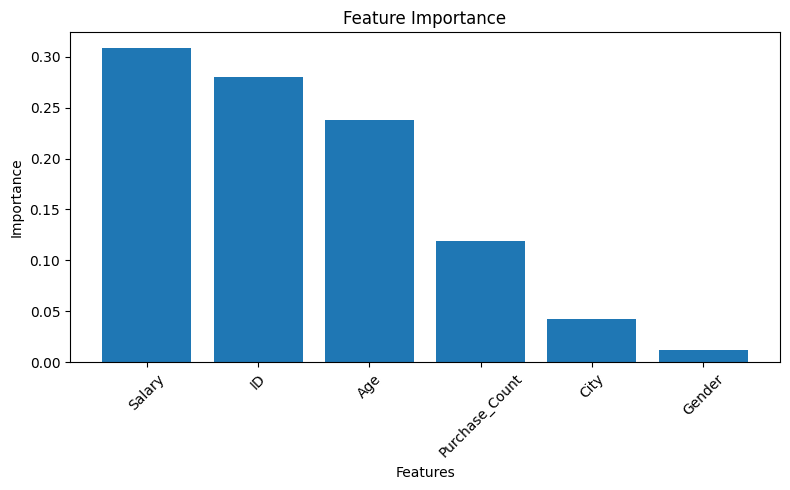

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_tree.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance_df)

plt.figure(figsize=(8,5))
plt.bar(feature_importance_df['Feature'],
        feature_importance_df['Importance'])
plt.title('Feature Importance')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

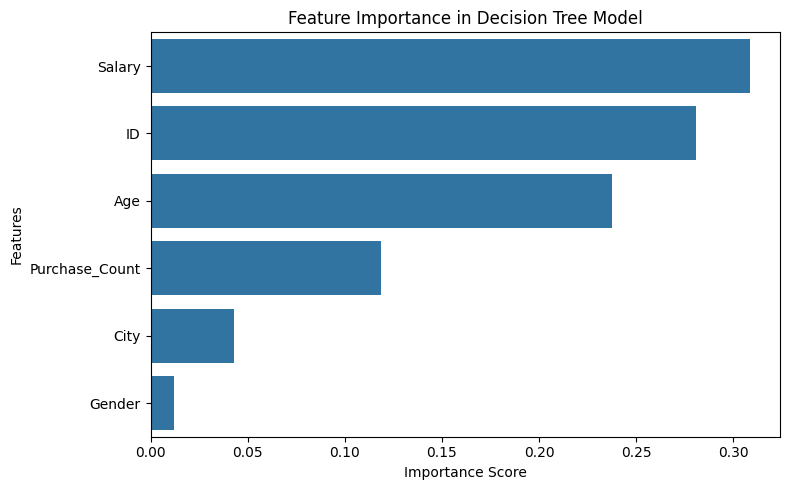

In [198]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance in Decision Tree Model')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.tight_layout()
plt.show()

In [ ]:
print(X.head())
print(y.head())

     ID  Age    Salary  Purchase_Count  Gender  City
0  1001   56  93850.04               4       0     1
1  1002   46  86284.78               9       1     2
2  1003   32  62118.27               7       1     2
3  1004   60  88974.23               5       0     0
4  1005   25  50679.37               2       1     0
0    0
1    1
2    0
3    1
4    1
Name: Subscribed, dtype: int64


In [ ]:
import pandas as pd

df = pd.read_csv("synthetic_dataset.csv")

print(df.head())
print(df.columns)

     ID  Age    Salary  Purchase_Count  Gender Subscribed       City
0  1001   56  93850.04               4  Female         No   Lalitpur
1  1002   46  86284.78               9    Male        Yes    Pokhara
2  1003   32  62118.27               7    Male         No    Pokhara
3  1004   60  88974.23               5  Female        Yes  Kathmandu
4  1005   25  50679.37               2    Male        Yes  Kathmandu
Index(['ID', 'Age', 'Salary', 'Purchase_Count', 'Gender', 'Subscribed',
       'City'],
      dtype='str')


In [ ]:
X = df.drop('Subscribed', axis=1)
y = df['Subscribed']

In [ ]:
X = pd.get_dummies(X, columns=['Gender', 'City'], drop_first=True)

In [ ]:
print(X.head())
print(y.head())

     ID  Age    Salary  Purchase_Count  Gender_Male  City_Lalitpur  \
0  1001   56  93850.04               4        False           True   
1  1002   46  86284.78               9         True          False   
2  1003   32  62118.27               7         True          False   
3  1004   60  88974.23               5        False          False   
4  1005   25  50679.37               2         True          False   

   City_Pokhara  
0         False  
1          True  
2          True  
3         False  
4         False  
0     No
1    Yes
2     No
3    Yes
4    Yes
Name: Subscribed, dtype: str


In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(320, 7)
(80, 7)


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.6125
Precision: 0.5641025641025641
Recall: 0.6111111111111112
F1 Score: 0.5866666666666667


In [ ]:
print("Actual labels:", y_test.unique())
print("Predicted labels:", pd.Series(y_pred).unique())

Actual labels: [1 0]
Predicted labels: [0 1]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label=1, zero_division=0))
print("Recall:", recall_score(y_test, y_pred, pos_label=1, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred, pos_label=1, zero_division=0))

Accuracy: 0.6125
Precision: 0.5641025641025641
Recall: 0.6111111111111112
F1 Score: 0.5866666666666667


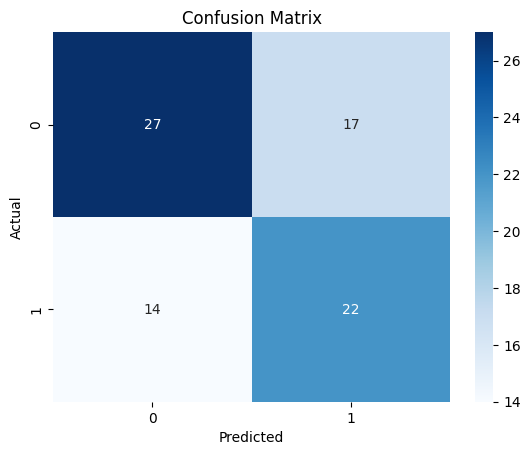

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

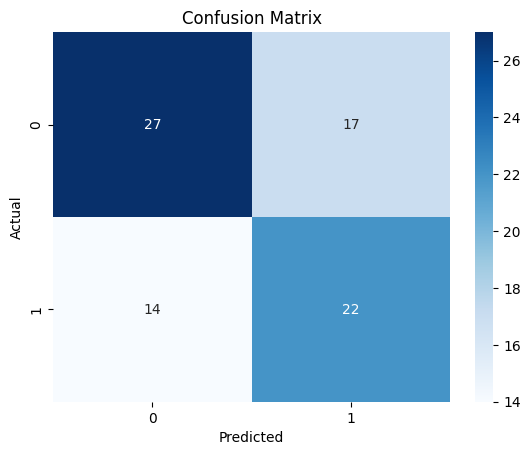

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

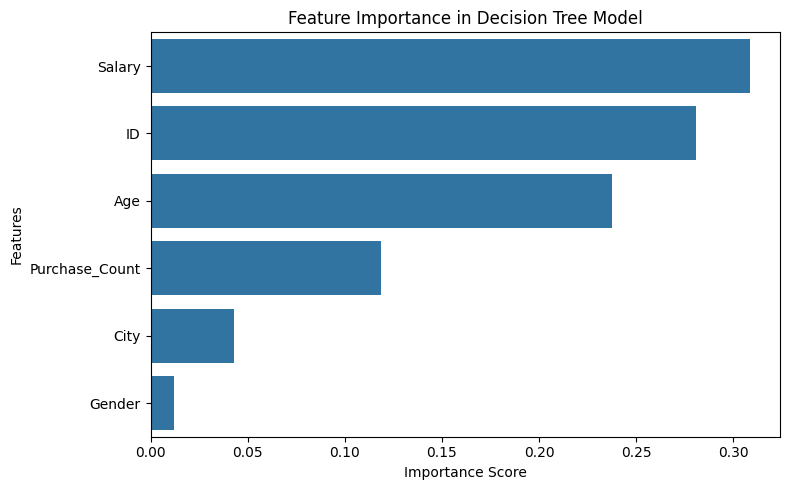

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance in Decision Tree Model')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.tight_layout()
plt.show()

In [199]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [200]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

          Feature  Importance
2  Purchase_Count    0.454227
0             Age    0.313907
1          Salary    0.221738
4   City_Lalitpur    0.007302
3          Gender    0.002826
5    City_Pokhara    0.000000


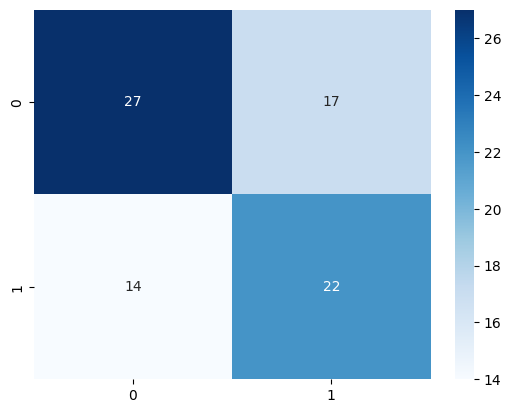

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.show()

In [201]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

          Feature  Importance
2  Purchase_Count    0.454227
0             Age    0.313907
1          Salary    0.221738
4   City_Lalitpur    0.007302
3          Gender    0.002826
5    City_Pokhara    0.000000


In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [ ]:
print(X.shape)
print(X.columns)

(400, 7)
Index(['ID', 'Age', 'Salary', 'Purchase_Count', 'Gender_Male', 'City_Lalitpur',
       'City_Pokhara'],
      dtype='str')


In [ ]:
print(model)

DecisionTreeClassifier(random_state=42)


In [202]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

          Feature  Importance
2  Purchase_Count    0.454227
0             Age    0.313907
1          Salary    0.221738
4   City_Lalitpur    0.007302
3          Gender    0.002826
5    City_Pokhara    0.000000


In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[42  2]
 [32  4]]


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[42  2]
 [32  4]]


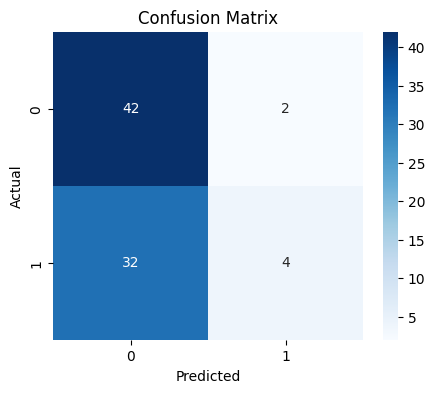

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
print("Number of X columns:", len(X.columns))
print("Number of model features:", len(model.feature_importances_))
print("X columns:", list(X.columns))

Number of X columns: 7
Number of model features: 6
X columns: ['ID', 'Age', 'Salary', 'Purchase_Count', 'Gender_Male', 'City_Lalitpur', 'City_Pokhara']


In [ ]:
print("Model was trained with:", model.n_features_in_, "features")
print("Current X has:", X.shape[1], "features")

Model was trained with: 6 features
Current X has: 7 features


In [205]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

          Feature  Importance
2  Purchase_Count    0.454227
0             Age    0.313907
1          Salary    0.221738
4   City_Lalitpur    0.007302
3          Gender    0.002826
5    City_Pokhara    0.000000


In [ ]:
print("Feature names stored in model:")
print(model.feature_names_in_)

Feature names stored in model:
['ID' 'Age' 'Salary' 'Purchase_Count' 'Gender' 'City']


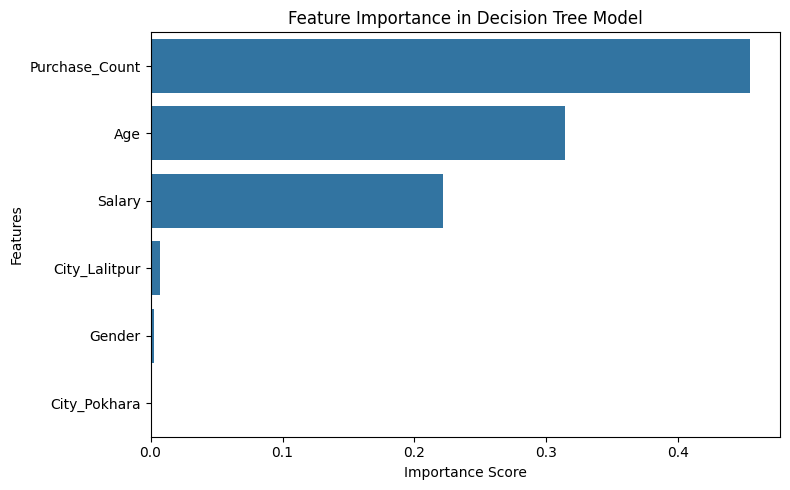

In [206]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance in Decision Tree Model')
plt.xlabel('Importance Score')
plt.ylabel('Features')

plt.tight_layout()
plt.show()

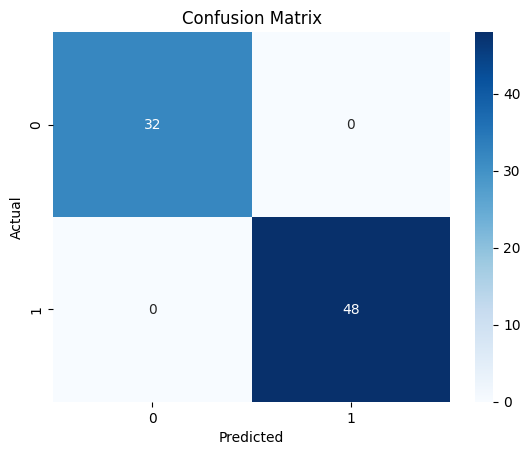

In [207]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()